<a href="https://colab.research.google.com/github/l22140161-dotcom/Analisis-y-visualizacion-de-datos/blob/main/Guia_Unidad5_DDDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows: 5050 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): Gender, Item Purchased, Category, Location, Size, Color, Season, S...
dbl  (5): Customer ID, Age, Purchase Amount (USD), Review Rating, Previous P...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 5,050
Columns: 17
$ `Customer ID`            <dbl> 2701, 521, 3157, 1687, 2929, 3583, 1135, 1411…
$ Age                      <dbl> 22, 51, 18, 22, 40, 23, 62, 61, 37, 42, 35, 4…
$ Gender                   <chr> "Female", "Male", "Female", "Male", "Female",…
$ `Item Purchased`         <chr> "T-shirt", "Sunglasses", "Shirt", "Gloves", "…
$ Category                 <chr> "Clothing", "Accessories", "Clothing", "Acces…
$ `Purchase Amount (USD)`  <dbl> 68.00, 84.00, 50.00, 75.00, 80.00, 41.00, 81.…
$ Location                 <chr> "California", "South Carolina", "Montana", "I…
$ Size                     <chr> "XL", "M", "M", "L", "L", "S", "M", "M", "M",…
$ Color                    <chr> "Olive", "White", "Black", "Red", "Yellow", "…
$ Season                   <chr> "Winter", "Spring", "Winter", "Fall", "Spring…
$ `Review Rating`          <dbl> 3.2, 3.9, 3.1, 4.2, 3.6, 3.4, NA, 4.0, 4.3, 2…
$ `Subscription Status`    <chr> "No", "Yes", "No", "No", "No", "No", "No", "N…
$ `Shipping Type

  Customer ID        Age              Gender       Item Purchased
 Min.   :   1   Min.   :18.00   Length   :5050   Length   :5050  
 1st Qu.:1252   1st Qu.:31.00   N.unique :   3   N.unique :  30  
 Median :2500   Median :44.00   N.blank  :   0   N.blank  :   0  
 Mean   :2520   Mean   :44.15   Min.nchar:   4   Min.nchar:   3  
 3rd Qu.:3741   3rd Qu.:57.00   Max.nchar:   6   Max.nchar:  10  
 Max.   :5099   Max.   :70.00                                    
                                                                 
      Category    Purchase Amount (USD)      Location           Size     
 Length   :5050   Min.   :  10.12       Length   :5050   Length   :5050  
 N.unique :   5   1st Qu.:  41.00       N.unique :  54   N.unique :   4  
 N.blank  :   0   Median :  65.00       N.blank  :   0   N.blank  :   0  
 Min.nchar:   8   Mean   : 144.77       Min.nchar:   4   Min.nchar:   1  
 Max.nchar:  11   3rd Qu.:  89.00       Max.nchar:  14   Max.nchar:   2  
                  Max.   :14

[1] "Customer ID"            "Age"                    "Gender"                
 [4] "Item Purchased"         "Category"               "Purchase Amount (USD)" 
 [7] "Location"               "Size"                   "Color"                 
[10] "Season"                 "Review Rating"          "Subscription Status"   
[13] "Shipping Type"          "Discount Applied"       "Previous Purchases"    
[16] "Payment Method"         "Frequency of Purchases"

# A tibble: 3 × 6
  gender total_compras promedio_compras clientes edad_promedio groups
  <chr>          <dbl>            <dbl>    <int>         <dbl> <chr> 
1 FEMALE       104317.             79.9     1306          44.2 drop  
2 MALE         172298.             64.7     2665          44.1 drop  
3 OTHER         28255.            744.        38          44.4 drop  


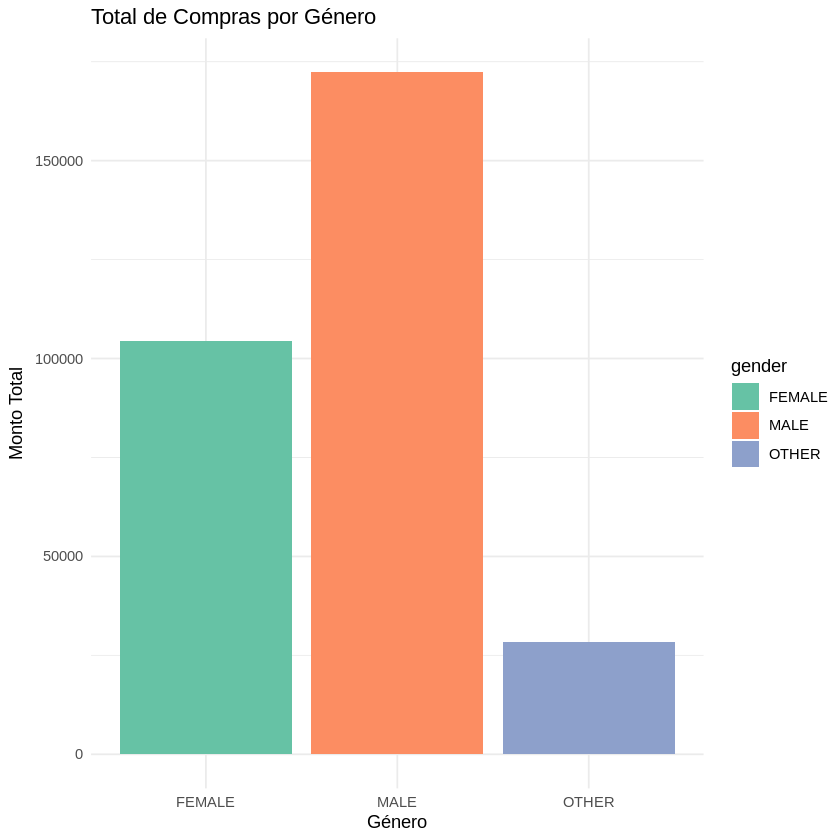

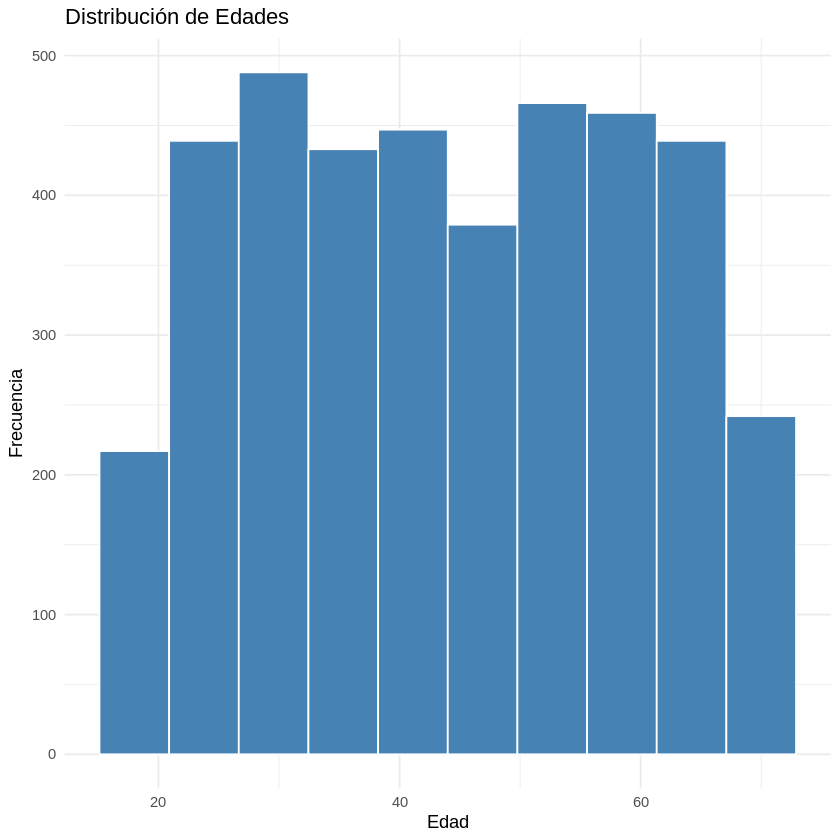

In [19]:
# R — Plantilla de análisis exploratorio (EDA)
library(tidyverse)
library(lubridate)

# 1. Importar datos
datos <- read_csv("customer_shopping_behavior.csv")

# 2. Explorar estructura
glimpse(datos)
summary(datos)
colnames(datos)

# 3. Limpiar y transformar
datos_limpios <- datos |>
  drop_na() |>
  mutate(gender = str_to_upper(Gender),
          age = as.numeric(Age),
          purchase = as.numeric(`Purchase Amount (USD)`))

# 4. Agregar KPIs
resumen <- datos_limpios |>
  group_by(gender) |>
  summarise(total_compras = sum(purchase),
             promedio_compras = mean(purchase),
             clientes = n(),
             edad_promedio = mean(age),
             groups = "drop")
 print(resumen)
# 5. Visualizar
ggplot(resumen, aes(x = gender, y = total_compras, fill = gender)) +
  geom_col(position = "dodge") +
  labs(title = "Total de Compras por Género",
       x = "Género", y = "Monto Total") +
  theme_minimal() +
  scale_fill_brewer(palette = 'Set2')

ggplot(datos_limpios,
       aes(x = age)) +

geom_histogram(bins = 10, fill = "steelblue", color = "white") +
    labs(title = "Distribución de Edades",
    x = "Edad", y = "Frecuencia") +
    theme_minimal()

Utilidad media esperada: $ 179054 
Probabilidad de pérdida: 2.93 %
IC 95%: [$ -7496 , $ 370234 ]


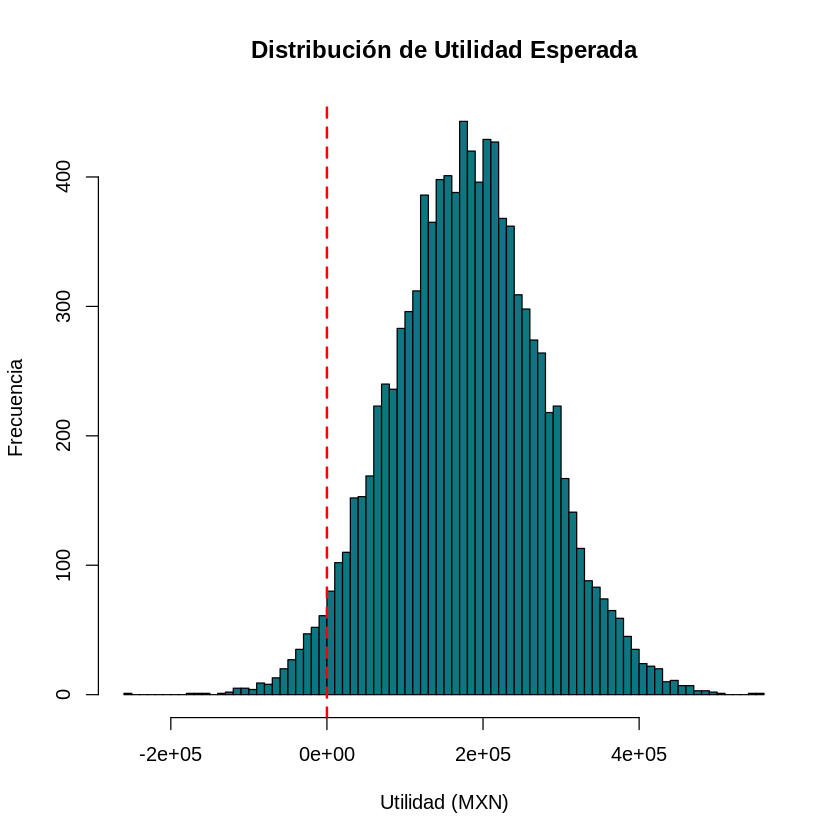

In [20]:
#Ejemplo en R — Simulación Monte Carlo simple
set.seed(42)
n_sim <- 10000

# Simular ingresos y costos con incertidumbre
ingresos <- rnorm(n_sim, mean = 500000, sd = 80000)
costos   <- rnorm(n_sim, mean = 320000, sd = 50000)
utilidad <- ingresos - costos

# Resultados
cat('Utilidad media esperada: $', round(mean(utilidad), 0), '\n')
cat('Probabilidad de pérdida:', mean(utilidad < 0) * 100, '%\n')
cat('IC 95%: [$', round(quantile(utilidad, 0.025), 0),
    ', $', round(quantile(utilidad, 0.975), 0), ']\n')

# Histograma de resultados
hist(utilidad, breaks = 60, col = '#0D7680',
     main = 'Distribución de Utilidad Esperada',
     xlab = 'Utilidad (MXN)', ylab = 'Frecuencia')
abline(v = 0, col = 'red', lwd = 2, lty = 2)
